In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.special import jn, jn_zeros
import pandas as pd
import pyvista as pv

In [2]:
colors = {
    "gray": {
        0: "#f8f9fa",
        1: "#f1f3f5",
        2: "#e9ecef",
        3: "#dee2e6",
        4: "#ced4da",
        5: "#adb5bd",
        6: "#868e96",
        7: "#495057",
        8: "#343a40",
        9: "#212529",
    },
    "red": {
        0: "#fff5f5",
        1: "#ffe3e3",
        2: "#ffc9c9",
        3: "#ffa8a8",
        4: "#ff8787",
        5: "#ff6b6b",
        6: "#fa5252",
        7: "#f03e3e",
        8: "#e03131",
        9: "#c92a2a",
    },
    "pink": {
        0: "#fff0f6",
        1: "#ffdeeb",
        2: "#fcc2d7",
        3: "#faa2c1",
        4: "#f783ac",
        5: "#f06595",
        6: "#e64980",
        7: "#d6336c",
        8: "#c2255c",
        9: "#a61e4d",
    },
    "grape": {
        0: "#f8f0fc",
        1: "#f3d9fa",
        2: "#eebefa",
        3: "#e599f7",
        4: "#da77f2",
        5: "#cc5de8",
        6: "#be4bdb",
        7: "#ae3ec9",
        8: "#9c36b5",
        9: "#862e9c",
    },
    "violet": {
        0: "#f3f0ff",
        1: "#e5dbff",
        2: "#d0bfff",
        3: "#b197fc",
        4: "#9775fa",
        5: "#845ef7",
        6: "#7950f2",
        7: "#7048e8",
        8: "#6741d9",
        9: "#5f3dc4",
    },
    "indigo": {
        0: "#edf2ff",
        1: "#dbe4ff",
        2: "#bac8ff",
        3: "#91a7ff",
        4: "#748ffc",
        5: "#5c7cfa",
        6: "#4c6ef5",
        7: "#4263eb",
        8: "#3b5bdb",
        9: "#364fc7",
    },
    "blue": {
        0: "#e7f5ff",
        1: "#d0ebff",
        2: "#a5d8ff",
        3: "#74c0fc",
        4: "#4dabf7",
        5: "#339af0",
        6: "#228be6",
        7: "#1c7ed6",
        8: "#1971c2",
        9: "#1864ab",
    },
    "cyan": {
        0: "#e3fafc",
        1: "#c5f6fa",
        2: "#99e9f2",
        3: "#66d9e8",
        4: "#3bc9db",
        5: "#22b8cf",
        6: "#15aabf",
        7: "#1098ad",
        8: "#0c8599",
        9: "#0b7285",
    },
    "teal": {
        0: "#e6fcf5",
        1: "#c3fae8",
        2: "#96f2d7",
        3: "#63e6be",
        4: "#38d9a9",
        5: "#20c997",
        6: "#12b886",
        7: "#0ca678",
        8: "#099268",
        9: "#087f5b",
    },
    "green": {
        0: "#ebfbee",
        1: "#d3f9d8",
        2: "#b2f2bb",
        3: "#8ce99a",
        4: "#69db7c",
        5: "#51cf66",
        6: "#40c057",
        7: "#37b24d",
        8: "#2f9e44",
        9: "#2b8a3e",
    },
    "lime": {
        0: "#f4fce3",
        1: "#e9fac8",
        2: "#d8f5a2",
        3: "#c0eb75",
        4: "#a9e34b",
        5: "#94d82d",
        6: "#82c91e",
        7: "#74b816",
        8: "#66a80f",
        9: "#5c940d",
    },
    "yellow": {
        0: "#fff9db",
        1: "#fff3bf",
        2: "#ffec99",
        3: "#ffe066",
        4: "#ffd43b",
        5: "#fcc419",
        6: "#fab005",
        7: "#f59f00",
        8: "#f08c00",
        9: "#e67700",
    },
    "orange": {
        0: "#fff4e6",
        1: "#ffe8cc",
        2: "#ffd8a8",
        3: "#ffc078",
        4: "#ffa94d",
        5: "#ff922b",
        6: "#fd7e14",
        7: "#f76707",
        8: "#e8590c",
        9: "#d9480f",
    },
    "mixed": {
        0: "#880e4f",
        1: "#1a237e",
        2: "#e65100",
        3: "#004d40",
        4: "#c92a2a",
    },
}

Figure 2(c): Vector field for RAnt dynamics in $(\psi, r)$-plane

In [ ]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, writers
from matplotlib.collections import LineCollection


class Streamlines(object):
    def __init__(
        self, X, Y, U, V, res=0.125, spacing=2, maxLen=500, detectLoops=True
    ):
        """
        Compute a set of streamlines covering the given velocity field.
        X and Y - 1D or 2D (e.g. generated by np.meshgrid) arrays of the
                  grid points. The mesh spacing is assumed to be uniform
                  in each dimension.
        U and V - 2D arrays of the velocity field.
        res - Sets the distance between successive points in each
              streamline (same units as X and Y)
        spacing - Sets the minimum density of streamlines, in grid points.
        maxLen - The maximum length of an individual streamline segment.
        detectLoops - Determines whether an attempt is made to stop extending
                      a given streamline before reaching maxLen points if
                      it forms a closed loop or reaches a velocity node.
        Plots are generated with the 'plot' or 'plotArrows' methods.
        """

        self.spacing = spacing
        self.detectLoops = detectLoops
        self.maxLen = maxLen
        self.res = res

        xa = np.asanyarray(X)
        ya = np.asanyarray(Y)
        self.x = xa if xa.ndim == 1 else xa[0]
        self.y = ya if ya.ndim == 1 else ya[:, 0]
        self.u = U
        self.v = V
        self.dx = (self.x[-1] - self.x[0]) / (self.x.size - 1)  # assume a regular grid
        self.dy = (self.y[-1] - self.y[0]) / (self.y.size - 1)  # assume a regular grid
        self.dr = self.res * np.sqrt(self.dx * self.dy)

        # marker for which regions have contours
        self.used = np.zeros(self.u.shape, dtype=bool)
        self.used[0] = True
        self.used[-1] = True
        self.used[:, 0] = True
        self.used[:, -1] = True

        # Don't try to compute streamlines in regions where there is no velocity data
        for i in range(self.x.size):
            for j in range(self.y.size):
                if self.u[j, i] == 0.0 and self.v[j, i] == 0.0:
                    self.used[j, i] = True

        # Make the streamlines
        self.streamlines = []
        while not self.used.all():
            nz = np.transpose(np.logical_not(self.used).nonzero())
            # Make a streamline starting at the first unrepresented grid point
            self.streamlines.append(
                self._makeStreamline(self.x[nz[0][1]], self.y[nz[0][0]])
            )

    def _interp(self, x, y):
        """ Compute the velocity at point (x,y) """
        i = (x - self.x[0]) / self.dx
        ai = i % 1

        j = (y - self.y[0]) / self.dy
        aj = j % 1

        i, j = int(i), int(j)

        # Bilinear interpolation
        u = (
            self.u[j, i] * (1 - ai) * (1 - aj)
            + self.u[j, i + 1] * ai * (1 - aj)
            + self.u[j + 1, i] * (1 - ai) * aj
            + self.u[j + 1, i + 1] * ai * aj
        )

        v = (
            self.v[j, i] * (1 - ai) * (1 - aj)
            + self.v[j, i + 1] * ai * (1 - aj)
            + self.v[j + 1, i] * (1 - ai) * aj
            + self.v[j + 1, i + 1] * ai * aj
        )

        self.used[j : j + self.spacing, i : i + self.spacing] = True

        return u, v

    def _makeStreamline(self, x0, y0):
        """
        Compute a streamline extending in both directions from the given point.
        """

        sx, sy = self._makeHalfStreamline(x0, y0, 1)  # forwards
        rx, ry = self._makeHalfStreamline(x0, y0, -1)  # backwards

        rx.reverse()
        ry.reverse()

        return rx + [x0] + sx, ry + [y0] + sy

    def _makeHalfStreamline(self, x0, y0, sign):
        """
        Compute a streamline extending in one direction from the given point.
        """

        xmin = self.x[0]
        xmax = self.x[-1]
        ymin = self.y[0]
        ymax = self.y[-1]

        sx = []
        sy = []

        x = x0
        y = y0
        i = 0
        while xmin < x < xmax and ymin < y < ymax:
            u, v = self._interp(x, y)
            theta = np.arctan2(v, u)

            x += sign * self.dr * np.cos(theta)
            y += sign * self.dr * np.sin(theta)
            sx.append(x)
            sy.append(y)

            i += 1

            if self.detectLoops and i % 10 == 0 and self._detectLoop(sx, sy):
                break

            if i > self.maxLen / 2:
                break

        return sx, sy

    def _detectLoop(self, xVals, yVals):
        """ Detect closed loops and nodes in a streamline. """
        x = xVals[-1]
        y = yVals[-1]
        D = np.array(
            [np.hypot(x - xj, y - yj) for xj, yj in zip(xVals[:-1], yVals[:-1])]
        )
        return (D < 0.9 * self.dr).any()


# See https://stackoverflow.com/questions/11578760/
# matplotlib-control-capstyle-of-line-collection-large-number-of-lines
# -----------------------------------------------------------------------------
import types
from matplotlib.backend_bases import GraphicsContextBase, RendererBase


class GC(GraphicsContextBase):
    def __init__(self):
        super().__init__()
        self._capstyle = "round"


def custom_new_gc(self):
    return GC()


RendererBase.new_gc = types.MethodType(custom_new_gc, RendererBase)


mpl.rcParams.update(mpl.rcParamsDefault)
#plt.rc("font", family="Futura")
plt.rc('text', usetex = True)
label_size = 40
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 
#plt.rc("xtick", fontsize=20)
#plt.rc("ytick", fontsize=20)

# -----------------------------------------------------------------------------
#Y, X = np.mgrid[-3:3:100j, -3:3:100j]
#U, V = -1 - X ** 2 + Y, 1 + X - X * Y ** 2
#Y, X = np.mgrid[0.001:2*np.pi:50j,0.001:2*np.pi:50j]
#U, V = np.cos(Y), (1-1/X)*np.sin(Y)
Y, X = np.mgrid[0.005:2*np.pi:50j,0.005:2*np.pi:50j]
V, U = np.cos(X), (1-1/Y)*np.sin(X)
speed = np.sqrt(U * U + V * V)

fig = plt.figure(figsize=(8, 4), dpi=300)
ax = fig.gca()#add_axes([0, 0, 1, 1], aspect=1)#, frameon=False)

lengths = []
colors = []
lines = []

cmap = plt.get_cmap("Blues_r")
#cmap = plt.get_cmap("Greens_r")
s = Streamlines(X, Y, U, V)
for streamline in s.streamlines:
    x, y = streamline
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    n = len(segments)

    D = np.sqrt(((points[1:] - points[:-1]) ** 2).sum(axis=-1))
    L = D.cumsum().reshape(n, 1) + np.random.uniform(0, 1)
    C = np.zeros((n, 3))
    C[:] = (L * 1.5) % 1

    C = cmap(((L * 1.5) % 1).ravel())

    linewidths = np.zeros(n)
    linewidths[:] = 2 - ((L.reshape(n) * 1.5) % 1)
    line = LineCollection(segments, color=C, linewidth=linewidths)

    lengths.append(L)
    colors.append(C)
    lines.append(line)

    ax.add_collection(line)

ax.set_ylim(0, np.pi),
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels(["$0$", r'$\frac{\pi}{2}$', r'$\pi$'])
ax.set_xlim(0, 2*np.pi),
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['$0$', r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$'])

ax.set_xlabel(r'$\psi$',usetex=True, fontsize=label_size)
ax.set_ylabel(r'$r$',usetex=True,rotation=0, fontsize=label_size)
ax.xaxis.set_label_coords(0.5,-0.2)
ax.yaxis.set_label_coords(-0.1,0.45)


#plt.savefig("phaseplot.pdf")
plt.show()

Figure 2(c): $r^*$ vs $\lambda$

In [3]:
atic = pd.read_csv('Data/rstTh.txt', header = None, sep ='\t')
expt = pd.read_csv('Data/LamVsRst.txt', header = None, sep ='\t')
print(atic)

           0         1
0   0.040000  6.250000
1   0.043838  5.702765
2   0.047677  5.243644
3   0.051515  4.852941
4   0.055354  4.516423
..       ...       ...
95  0.404646  0.617823
96  0.408485  0.612018
97  0.412323  0.606320
98  0.416162  0.600728
99  0.420000  0.595238

[100 rows x 2 columns]


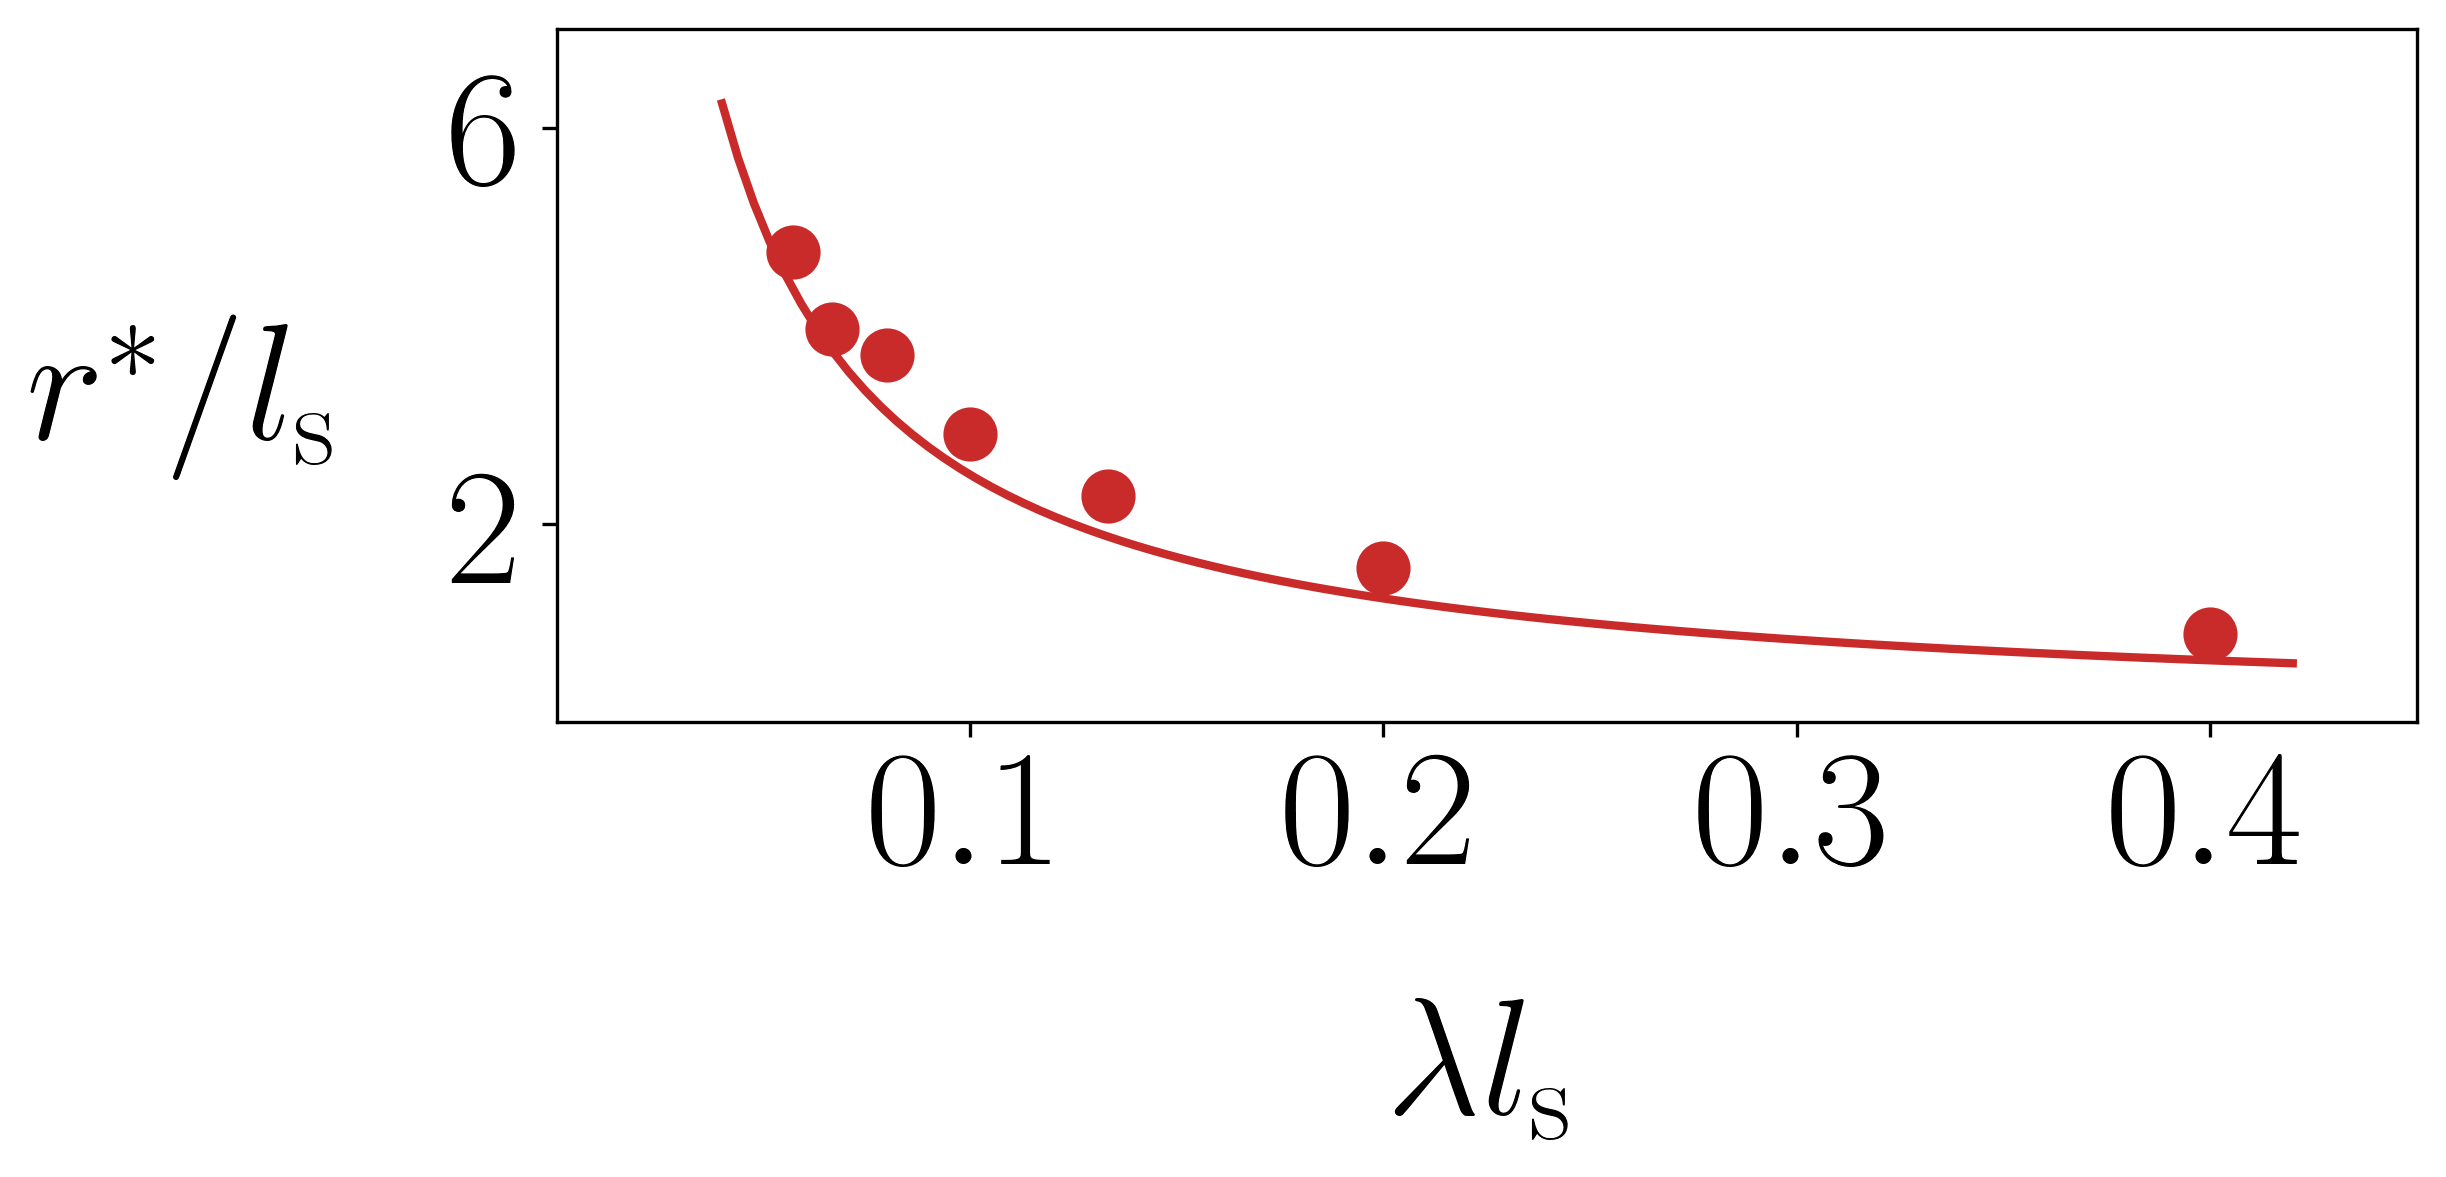

In [23]:
mpl.rcParams.update(mpl.rcParamsDefault)
label_size = 40
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 

#plt.rc("font", family="Roboto Condensed")
#plt.rc("xtick", labelsize="medium")
plt.rcParams.update({"text.usetex": True})

fig = plt.figure(figsize=(8, 3), dpi=300)
ax = plt.subplot(xlim=[0, 0.45], ylim=[0, 7])

linewidth = 2
linestyle = "-"
#color = "%.2f" % (0.0)
color = colors["red"][9]
ax.plot(atic[0],atic[1],
            color=color,
            clip_on=False,
            linewidth=linewidth,
            linestyle=linestyle,
            )
ax.plot(expt[0],expt[1],
            color=color,
            clip_on=False,
            marker='o',
            linestyle="None",
            markersize=12,
            )
ax.set_xlabel(r'$\lambda l_{\rm s}$',usetex=True, fontsize=label_size)
ax.set_ylabel(r'$r^*/l_{\rm s}$',usetex=True,rotation=0, fontsize=label_size)
ax.set_xticks([0.1, 0.2, 0.3, 0.4])
ax.set_yticks([2, 6])
#ax.set_yticklabels([r'$-\pi$', '$\pi$'],usetex=True)

ax.xaxis.set_label_coords(0.5,-0.4)
ax.yaxis.set_label_coords(-0.2,0.35)

#ax.spines["right"].set_visible(False)
#ax.spines["top"].set_visible(False)
ax.spines["right"].set_position(("data", 0.45))
ax.spines["top"].set_position(("data", 7.0))
ax.spines["left"].set_position(("data", 0.0))
ax.spines["bottom"].set_position(("data", 0.0))

plt.show()

Figure 4(b)

In [9]:
curv = pd.read_csv('Data/curvature.txt', header = None, sep =' ')
print(curv[5])

0      0.170565
1      0.171799
2      0.173027
3      0.174392
4      0.175674
         ...   
595    0.185635
596    0.185471
597    0.185313
598    0.185277
599    0.185177
Name: 5, Length: 600, dtype: float64


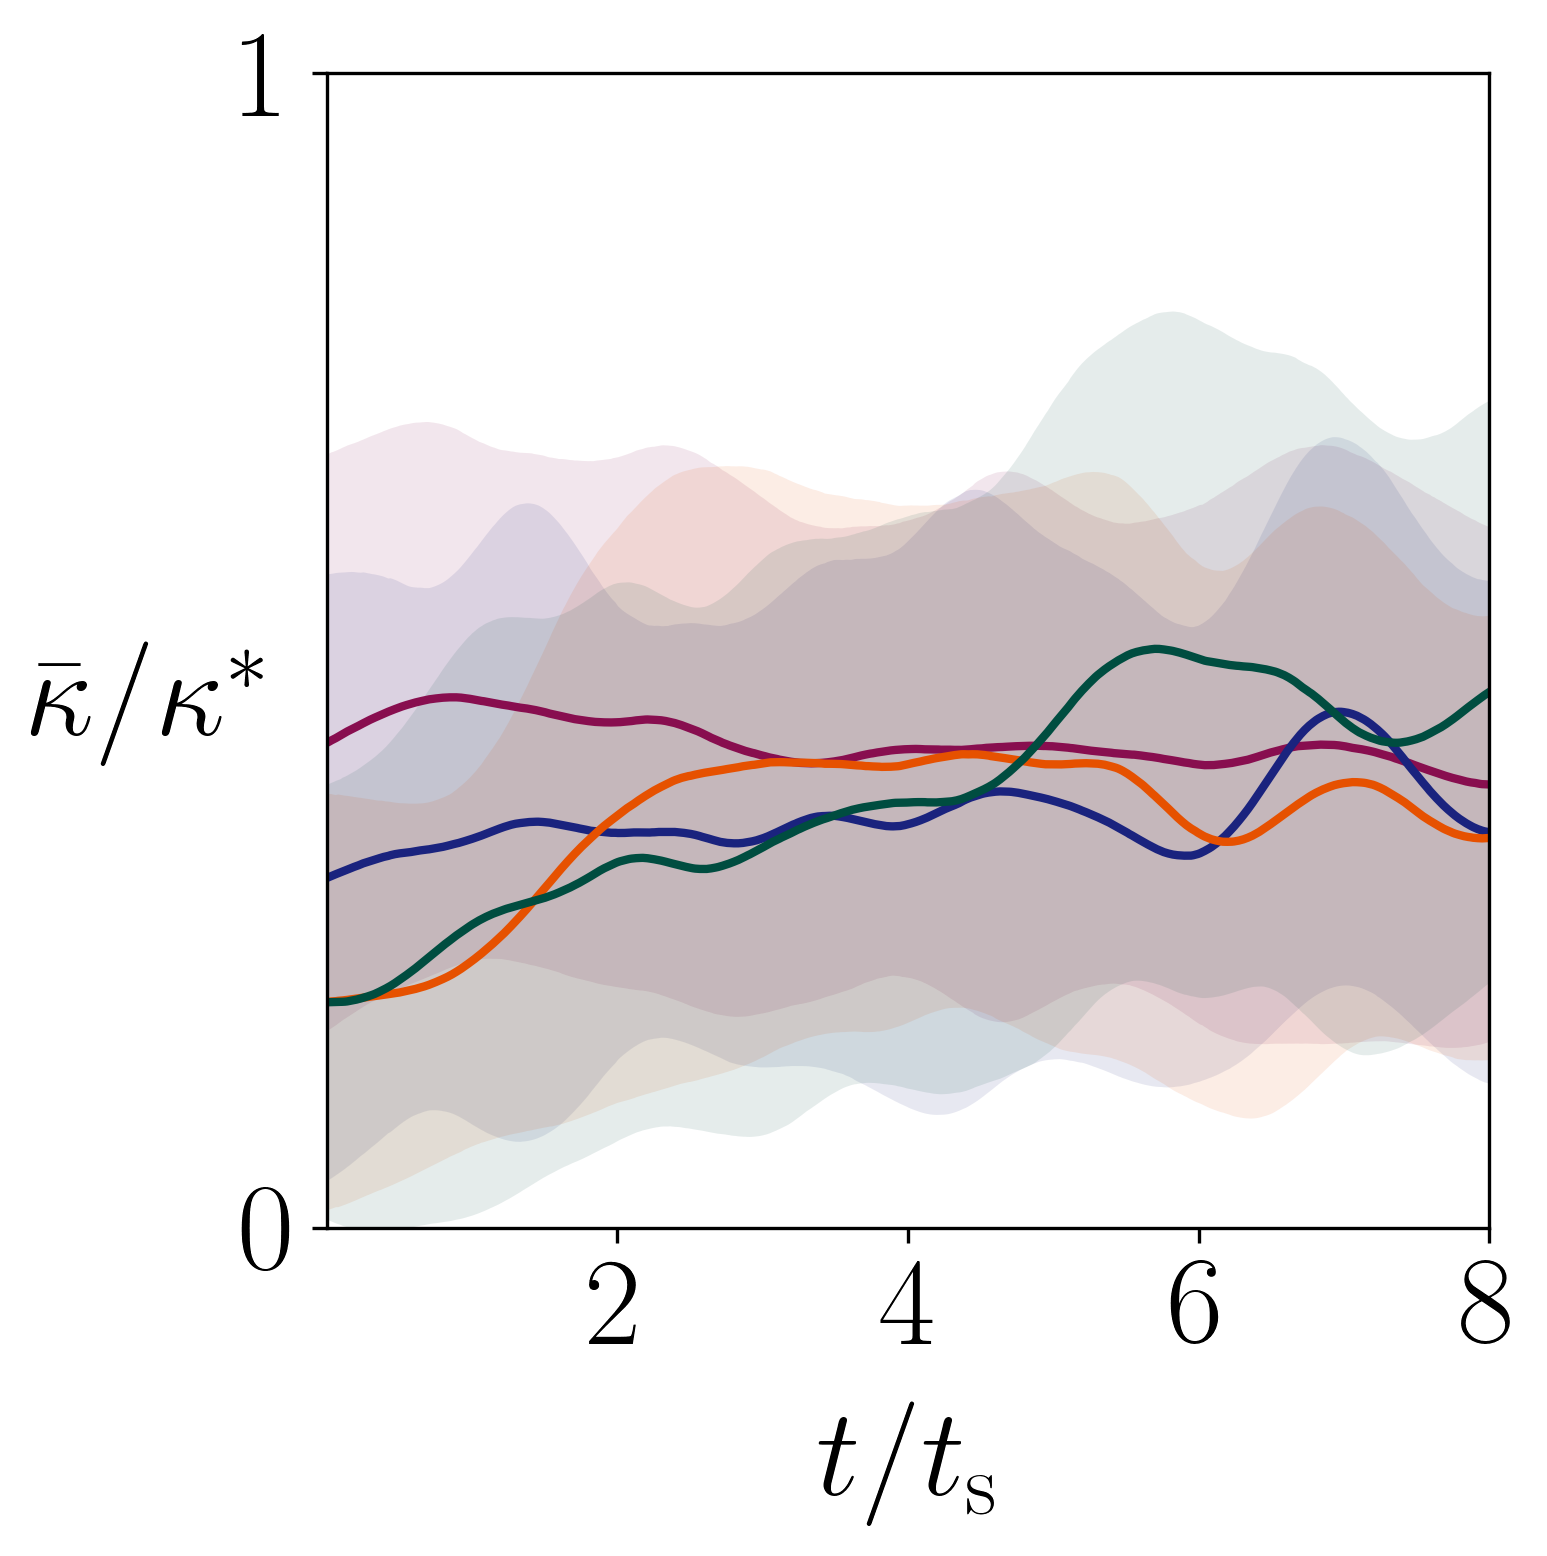

In [10]:
mpl.rcParams.update(mpl.rcParamsDefault)
label_size = 30
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 

plt.rcParams.update({"text.usetex": True})
fig = plt.figure(figsize=(5, 5), dpi=300)
ax = plt.subplot(xlim=[0, 8], ylim=[0, 1])

linewidth = 2
linestyle = "-"
color = colors['mixed']
ax.fill_between(curv[0], curv[5], curv[9], facecolor=color[0], alpha=0.1, zorder=-40)
ax.plot(curv[0],curv[1],
            color=color[0],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(curv[0], curv[6], curv[10], facecolor=color[1], alpha=0.1, zorder=-40)
ax.plot(curv[0],curv[2],
            color=color[1],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(curv[0], curv[7], curv[11], facecolor=color[2], alpha=0.1, zorder=-40)
ax.plot(curv[0],curv[3],
            color=color[2],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(curv[0], curv[8], curv[12], facecolor=color[3], alpha=0.1, zorder=-40)
ax.plot(curv[0],curv[4],
            color=color[3],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

#ax.set_yscale('log')
ax.set_xlabel(r'$t/t_{\rm{s}}$',usetex=True, fontsize=label_size)
ax.set_ylabel(r'$\bar{\kappa}/\kappa^*$',usetex=True,rotation=0, fontsize=label_size)
ax.set_xticks([2, 4, 6, 8])
ax.set_yticks([0, 1])

ax.xaxis.set_label_coords(0.5,-0.15)
ax.yaxis.set_label_coords(-0.15,0.4)

ax.spines["right"].set_position(("data", 8.0))
ax.spines["top"].set_position(("data", 1.0))
ax.spines["left"].set_position(("data", 0.0))
ax.spines["bottom"].set_position(("data", 0.0))

plt.show()

In [11]:
exc1 = pd.read_csv('Data/excavProgress_C1.txt', header = None, sep =' ')
exc2 = pd.read_csv('Data/excavProgress_C2.txt', header = None, sep =' ')
exc3 = pd.read_csv('Data/excavProgress_C3.txt', header = None, sep =' ')
exc4 = pd.read_csv('Data/excavProgress_C4.txt', header = None, sep =' ')
print(exc2[1])

0      0.006042
1      0.006047
2      0.006082
3      0.006207
4      0.006460
         ...   
301    0.135425
302    0.136172
303    0.136885
304    0.137517
305    0.138036
Name: 1, Length: 306, dtype: float64


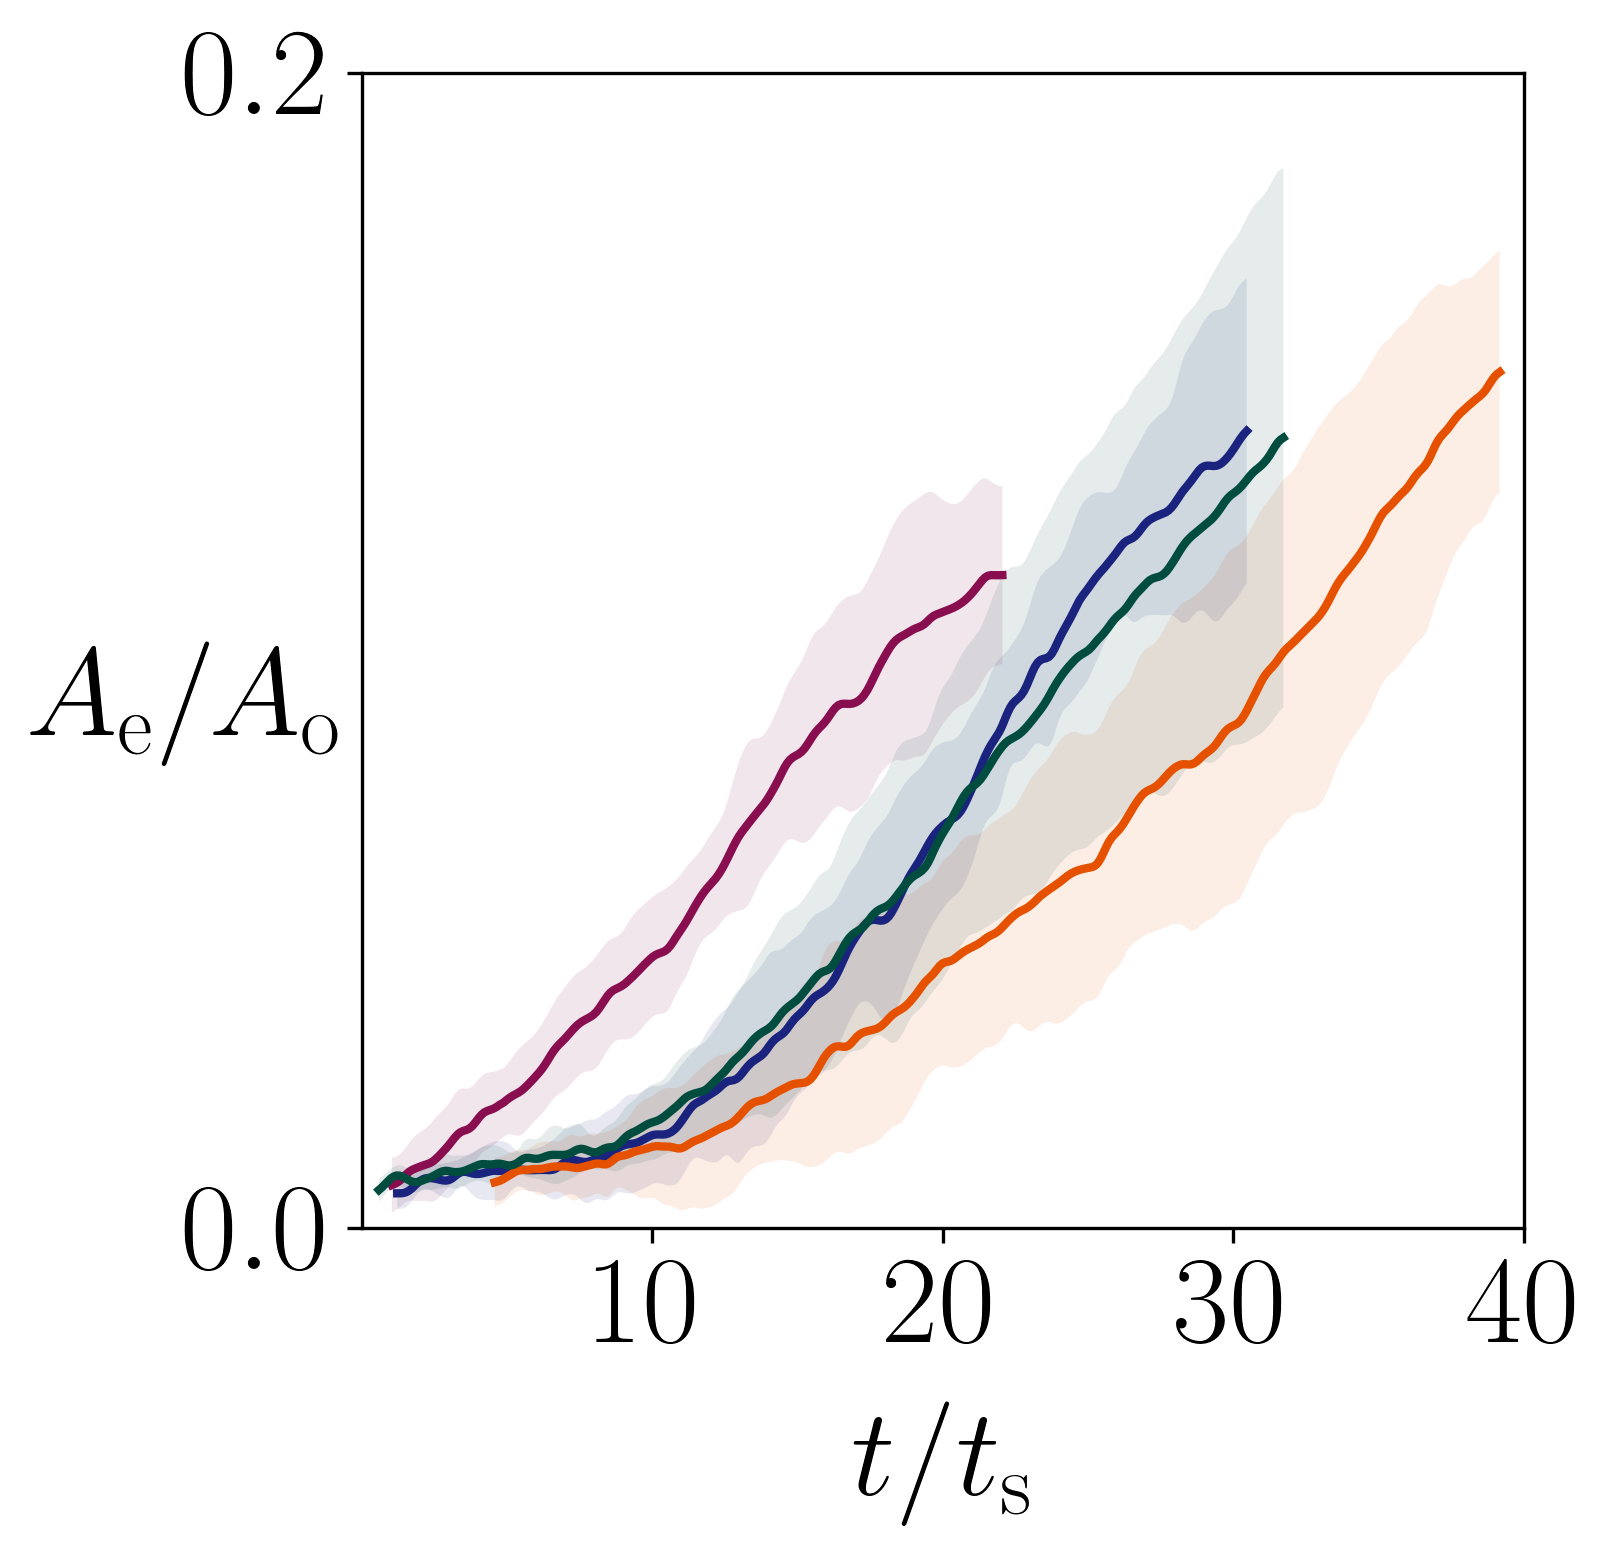

In [12]:
mpl.rcParams.update(mpl.rcParamsDefault)
label_size = 30
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 

plt.rcParams.update({"text.usetex": True})
fig = plt.figure(figsize=(5, 5), dpi=300)
ax = plt.subplot(xlim=[0, 40], ylim=[0, 0.2])

linewidth = 2
linestyle = "-"
color = colors['mixed']
ax.fill_between(exc1[0], exc1[2], exc1[3], facecolor=color[0], alpha=0.1, zorder=-40)
ax.plot(exc1[0],exc1[1],
            color=color[0],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(exc2[0], exc2[2], exc2[3], facecolor=color[1], alpha=0.1, zorder=-40)
ax.plot(exc2[0],exc2[1],
            color=color[1],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(exc3[0], exc3[2], exc3[3], facecolor=color[2], alpha=0.1, zorder=-40)
ax.plot(exc3[0],exc3[1],
            color=color[2],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(exc4[0], exc4[2], exc4[3], facecolor=color[3], alpha=0.1, zorder=-40)
ax.plot(exc4[0],exc4[1],
            color=color[3],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

#ax.set_yscale('log')
ax.set_xlabel(r'$t/t_{\rm{s}}$',usetex=True, fontsize=label_size)
ax.set_ylabel(r'$A_{\rm{e}}/A_{\rm{o}}$',usetex=True,rotation=0, fontsize=label_size)
ax.set_xticks([10, 20, 30, 40])
ax.set_yticks([0, 0.2])

ax.xaxis.set_label_coords(0.5,-0.15)
ax.yaxis.set_label_coords(-0.15,0.4)

ax.spines["right"].set_position(("data", 40))
ax.spines["top"].set_position(("data", 0.2))
ax.spines["left"].set_position(("data", 0.0))
ax.spines["bottom"].set_position(("data", 0.0))

plt.show()

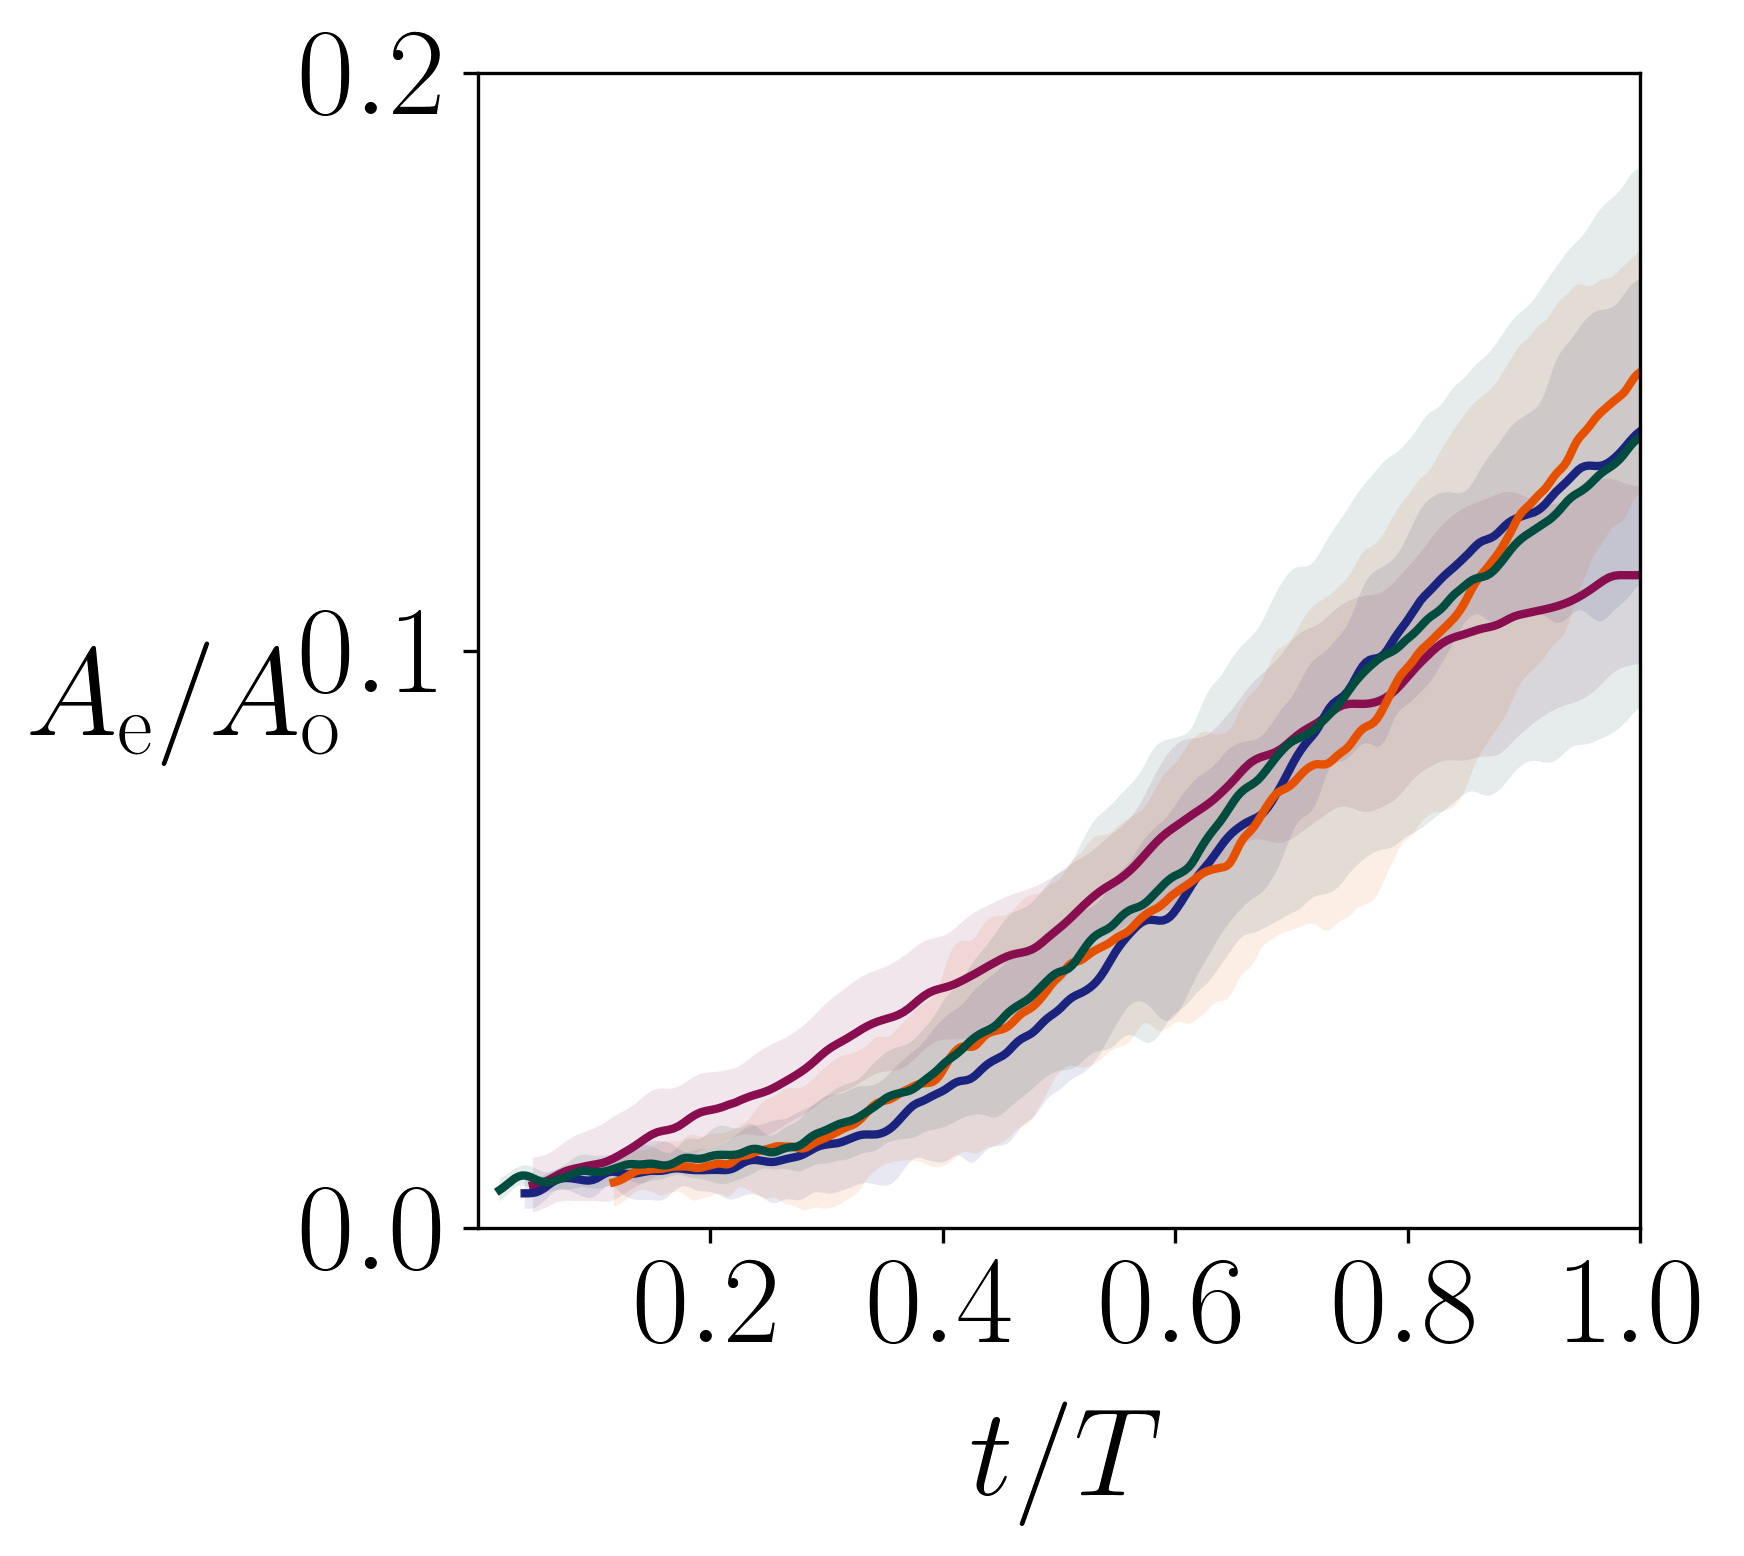

In [13]:
mpl.rcParams.update(mpl.rcParamsDefault)
label_size = 30
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 

plt.rcParams.update({"text.usetex": True})
fig = plt.figure(figsize=(5, 5), dpi=300)
ax = plt.subplot(xlim=[0, 1], ylim=[0, 0.2])

linewidth = 2
linestyle = "-"
color = colors['mixed']
ax.fill_between(exc1[0]/np.max(exc1[0]), exc1[2], exc1[3], facecolor=color[0], alpha=0.1, zorder=-40)
ax.plot(exc1[0]/np.max(exc1[0]),exc1[1],
            color=color[0],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(exc2[0]/np.max(exc2[0]), exc2[2], exc2[3], facecolor=color[1], alpha=0.1, zorder=-40)
ax.plot(exc2[0]/np.max(exc2[0]),exc2[1],
            color=color[1],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(exc3[0]/np.max(exc3[0]), exc3[2], exc3[3], facecolor=color[2], alpha=0.1, zorder=-40)
ax.plot(exc3[0]/np.max(exc3[0]),exc3[1],
            color=color[2],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

ax.fill_between(exc4[0]/np.max(exc4[0]), exc4[2], exc4[3], facecolor=color[3], alpha=0.1, zorder=-40)
ax.plot(exc4[0]/np.max(exc4[0]),exc4[1],
            color=color[3],
            clip_on=True,
            linewidth=linewidth,
            linestyle=linestyle,
            )

#ax.set_yscale('log')
ax.set_xlabel(r'$t/T$',usetex=True, fontsize=label_size)
ax.set_ylabel(r'$A_{\rm{e}}/A_{\rm{o}}$',usetex=True,rotation=0, fontsize=label_size)
ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0, 0.1, 0.2])

ax.xaxis.set_label_coords(0.5,-0.15)
ax.yaxis.set_label_coords(-0.25,0.4)

ax.spines["right"].set_position(("data", 1))
ax.spines["top"].set_position(("data", 0.2))
ax.spines["left"].set_position(("data", 0.0))
ax.spines["bottom"].set_position(("data", 0.0))

plt.show()

In [14]:
clst = pd.read_csv('Data/avClustArea.txt', header = None, sep =' ')
print(clst)

      0         1         2
0  0.25  0.004988  0.000873
1  0.50  0.011719  0.006766
2  0.75  0.013795  0.005694
3  1.00  0.021751  0.006748


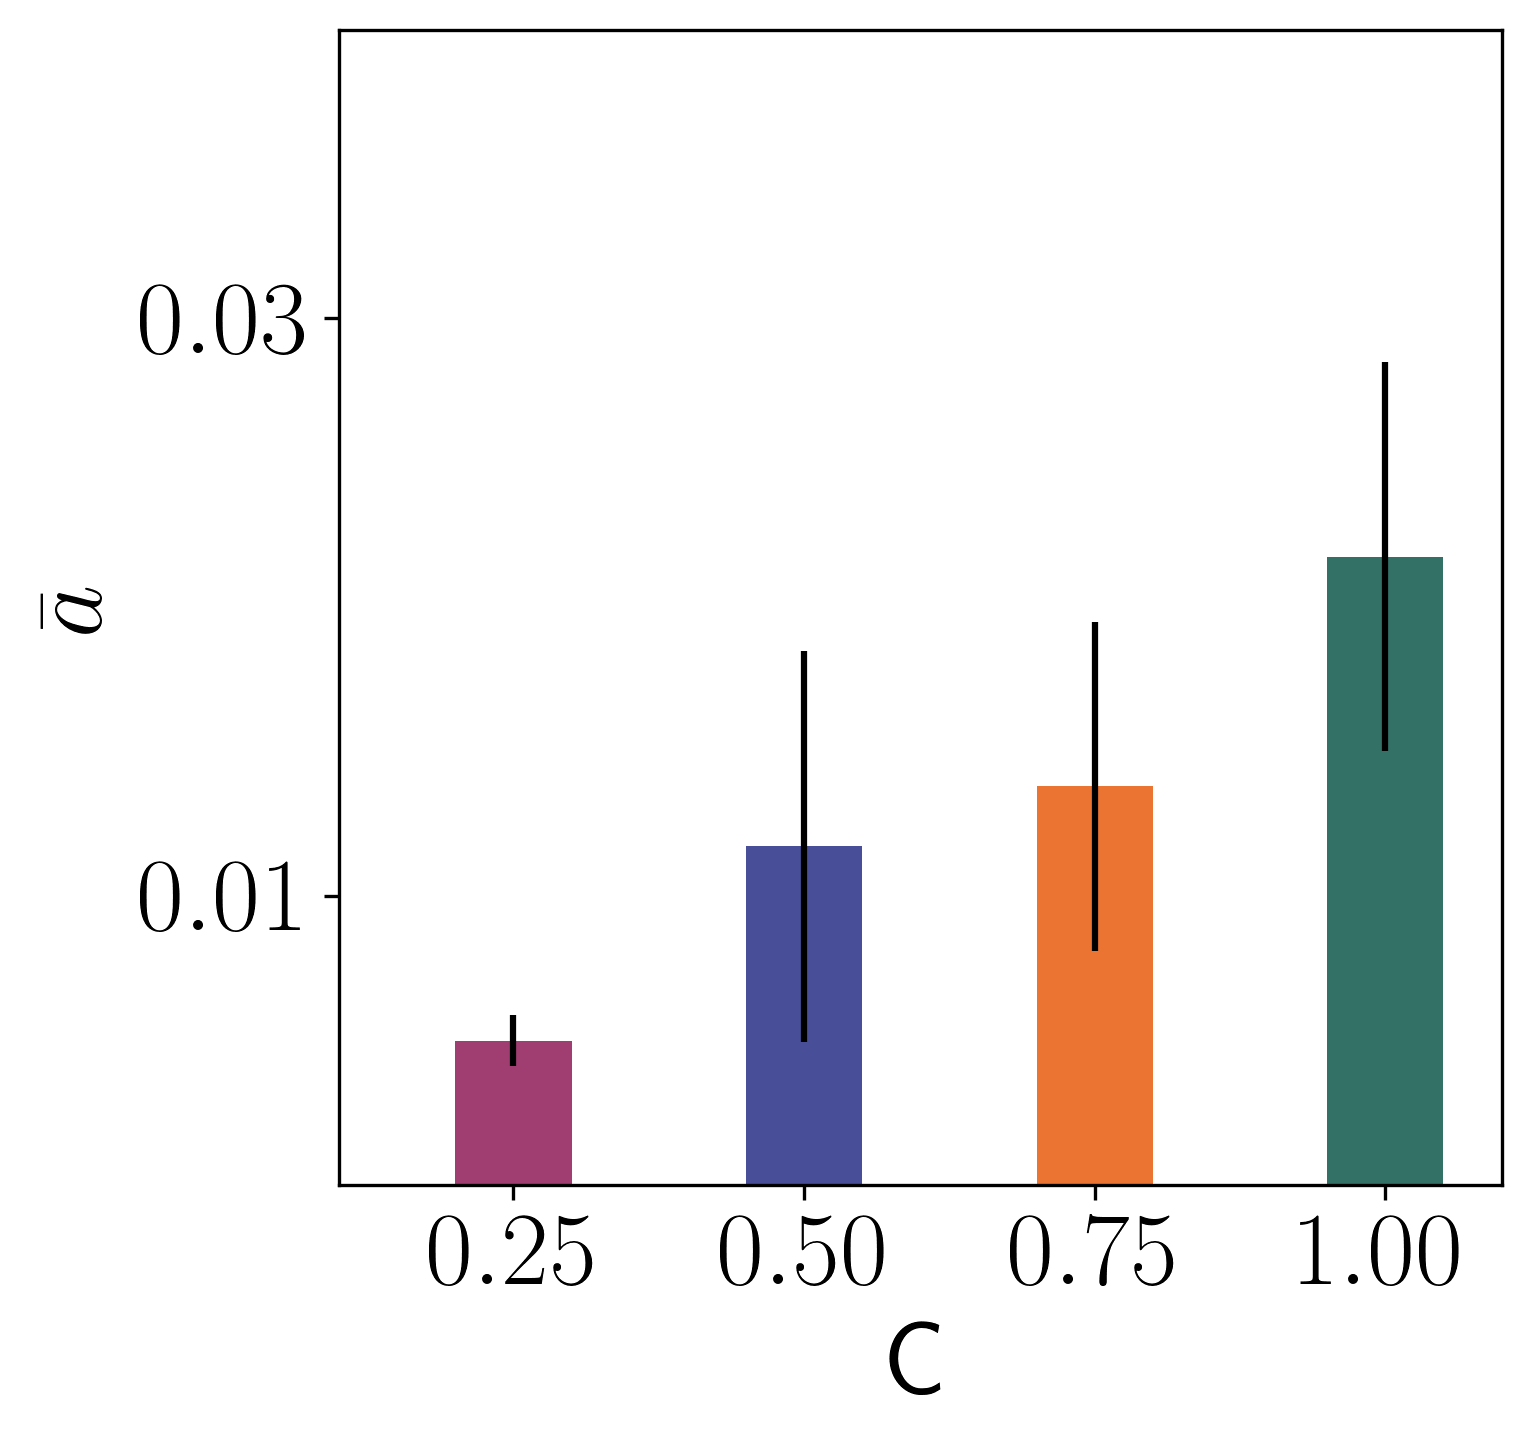

In [18]:
N = 4
ind = np.arange(N)    # the x locations for the groups
width = 0.1       # the width of the bars: can also be len(x) sequence

mpl.rcParams.update(mpl.rcParamsDefault)
label_size = 25
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 

color = colors['mixed']
plt.rcParams.update({"text.usetex": True})
fig = plt.figure(figsize=(5, 5), dpi=300)
ax = plt.subplot(xlim=[0.1, 1.1], ylim=[0, 0.04])
#ax = plt.gca()

p1 = ax.bar(clst[0], clst[1], width, yerr=clst[2], color=[color[0], color[1], color[2], color[3]], alpha = 0.8)

ax.set_ylabel(r'$\bar{a}$',usetex=True, fontsize=label_size)
ax.set_xlabel(r'$\textsf{C}$',usetex=True, fontsize=label_size)
ax.set_xticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0.01, 0.03])

plt.show()

In [19]:
lamb = pd.read_csv('Data/eigenVPerim.txt', header = None, sep =' ')
print(lamb)

      0         1         2
0  0.25  0.090596  0.016661
1  0.50  0.088038  0.009257
2  0.75  0.060413  0.015549
3  1.00  0.048895  0.020472


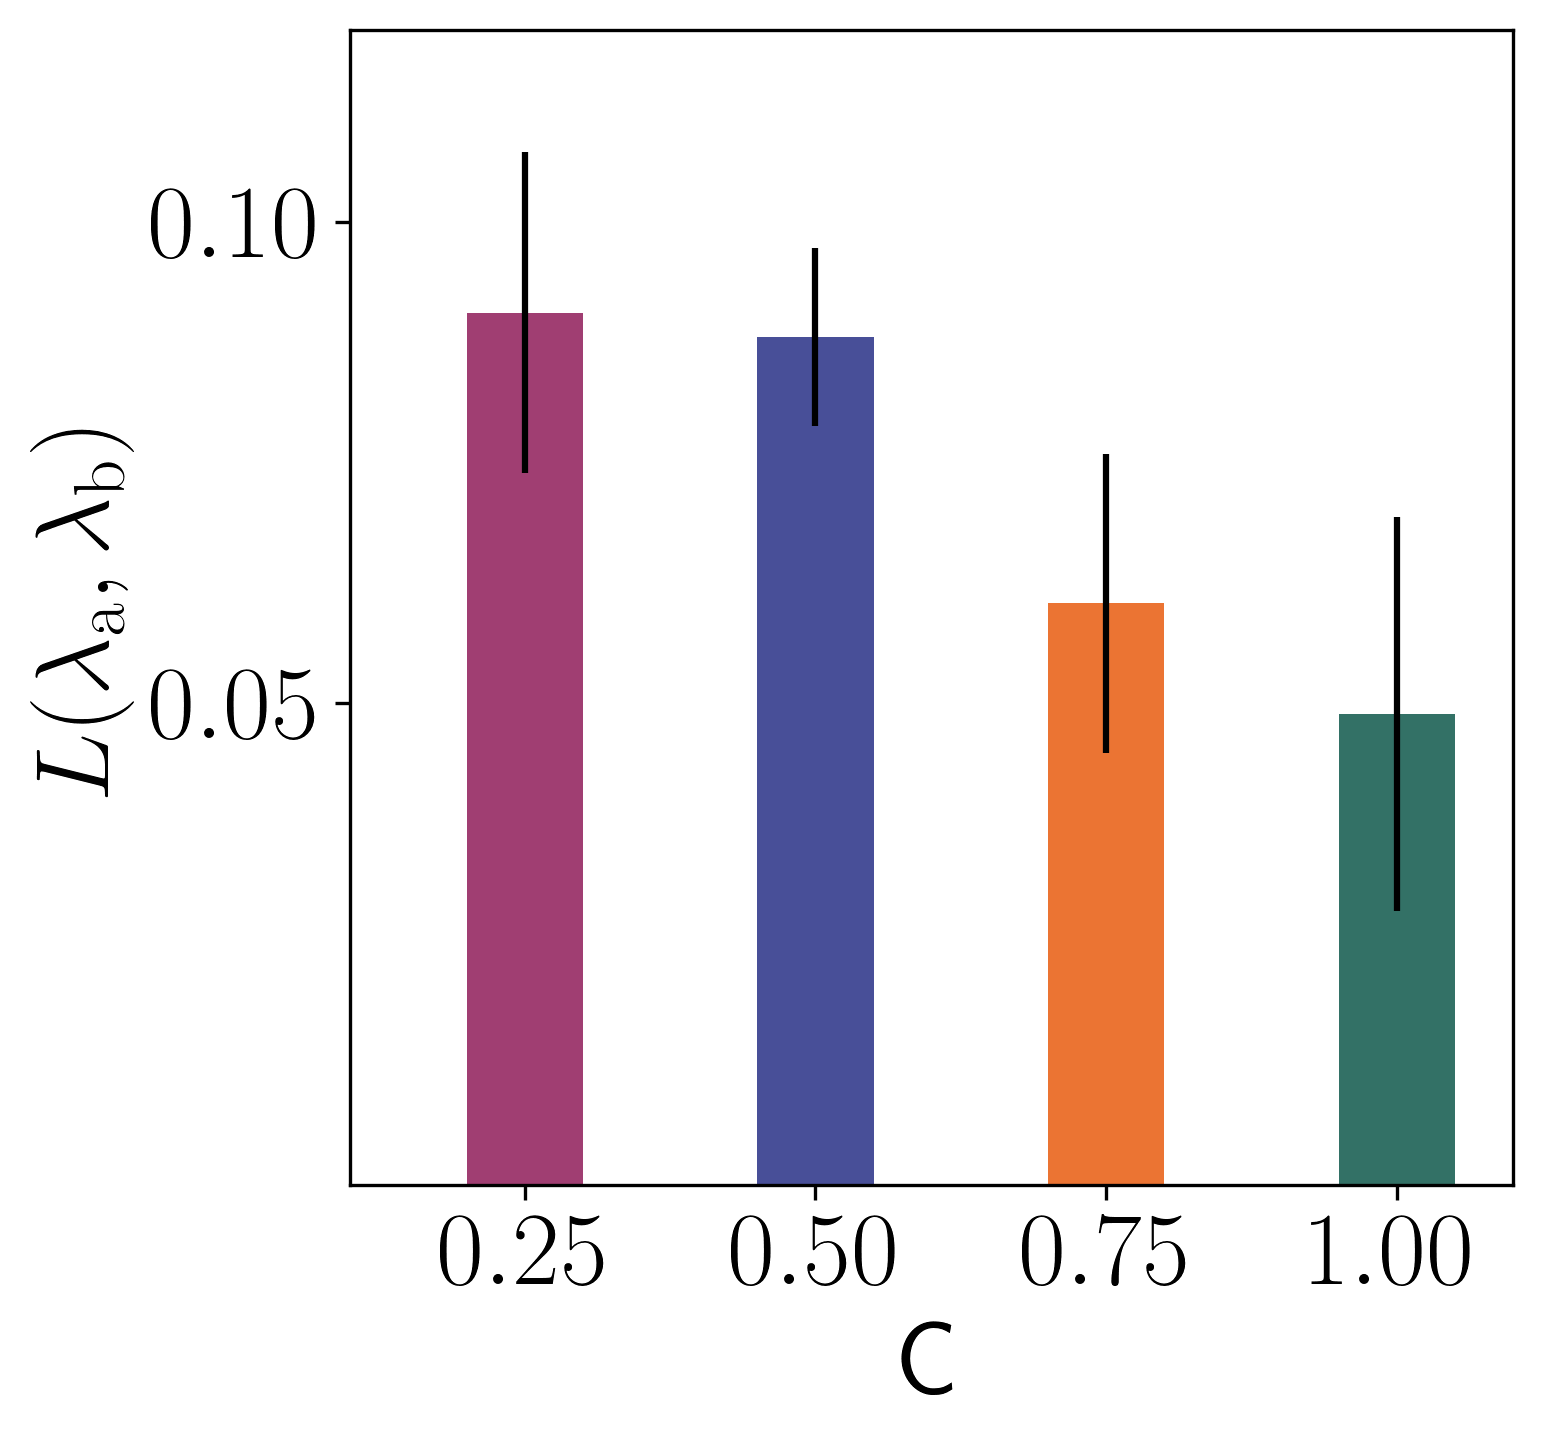

In [21]:
N = 4
ind = np.arange(N)    # the x locations for the groups
width = 0.1       # the width of the bars: can also be len(x) sequence

mpl.rcParams.update(mpl.rcParamsDefault)
label_size = 25
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 

plt.rcParams.update({"text.usetex": True})
fig = plt.figure(figsize=(5, 5), dpi=300)
ax = plt.subplot(xlim=[0.1, 1.1], ylim=[0, 0.12])
#ax = plt.gca()

p1 = ax.bar(lamb[0], lamb[1], width, yerr=lamb[2], color=[color[0], color[1], color[2], color[3]], alpha = 0.8)

ax.set_ylabel(r'$L(\lambda_{\rm{a}},\lambda_{\rm{b}})$',usetex=True, fontsize=label_size)
ax.set_xlabel(r'$\textsf{C}$',usetex=True, fontsize=label_size)
ax.set_xticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0.05, 0.1])

plt.show()

Figure 5(b)

In [ ]:
clust = pd.read_csv('Data/clusterSize.txt', header = None, sep =' ')
print(clust)

In [ ]:
N = 4
ind = np.arange(N)    # the x locations for the groups
width = 0.3       # the width of the bars: can also be len(x) sequence

mpl.rcParams.update(mpl.rcParamsDefault)
label_size = 20
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 
color = colors['mixed']

plt.rcParams.update({"text.usetex": True})
fig = plt.figure(figsize=(5, 2), dpi=300)
ax = plt.subplot(xlim=[0.5, 4.5], ylim=[0, 0.2])

p1 = ax.bar(clust[0], clust[1], width, yerr=clust[2], color=[color[0], color[1], color[2], color[3]], alpha = 0.8)

ax.set_ylabel(r'$A_{\rm{e}}/A_{\rm{o}}$',usetex=True, fontsize=label_size)
#ax.set_xlabel(r'$\textsf{C}$',usetex=True, fontsize=label_size)
ax.set_xticks([1,2,3,4])
ax.set_xticklabels([r"$\rm{A}$",r"$\rm{B}$",r"$\rm{C}$",r"$\rm{D}$"])
ax.set_yticks([0.05, 0.15])

plt.show()

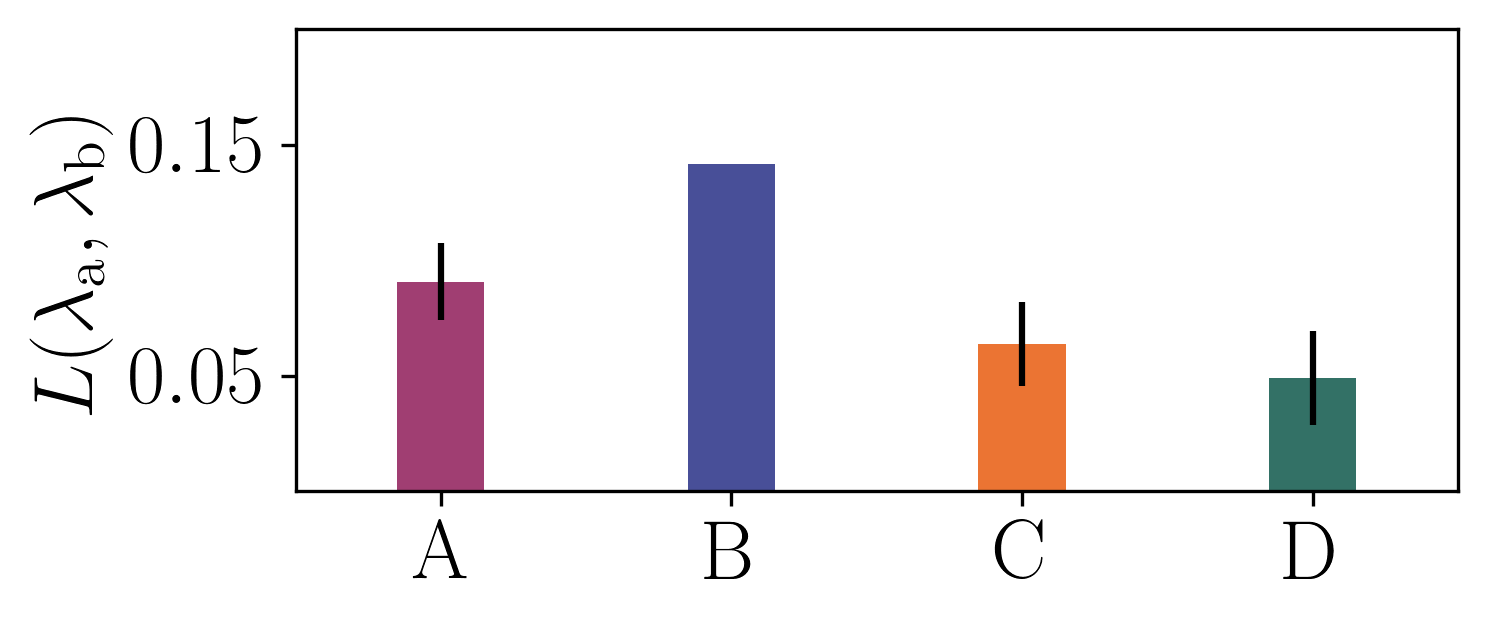

In [84]:
peri = pd.read_csv('Data/periSize.txt', header = None, sep =' ')
N = 4
ind = np.arange(N)    # the x locations for the groups
width = 0.3       # the width of the bars: can also be len(x) sequence

mpl.rcParams.update(mpl.rcParamsDefault)
label_size = 20
mpl.rcParams['xtick.labelsize'] = label_size 
mpl.rcParams['ytick.labelsize'] = label_size 
color = colors['mixed']

plt.rcParams.update({"text.usetex": True})
fig = plt.figure(figsize=(5, 2), dpi=300)
ax = plt.subplot(xlim=[0.5, 4.5], ylim=[0, 0.2])

p1 = ax.bar(peri[0], peri[1], width, yerr=peri[2], color=[color[0], color[1], color[2], color[3]], alpha = 0.8)

ax.set_ylabel(r'$L(\lambda_{\rm{a}},\lambda_{\rm{b}})$',usetex=True, fontsize=label_size)
#ax.set_xlabel(r'$\textsf{C}$',usetex=True, fontsize=label_size)
ax.set_xticks([1,2,3,4])
ax.set_xticklabels([r"$\rm{A}$",r"$\rm{B}$",r"$\rm{C}$",r"$\rm{D}$"])
ax.set_yticks([0.05, 0.15])

plt.show()

Figure 5(d): Contour plots

In [4]:
reader = pv.get_reader("Data/constructionSimple_29Dec.vtu")
print(f"Number of point arrays: {reader.number_point_arrays}")
print(f"Available point data:   {reader.point_array_names}")
print(f"Number of cell arrays:  {reader.number_cell_arrays}")
print(f"Available cell data:    {reader.cell_array_names}")
print(f"Available point arrays: {reader.point_array_names}")

Number of point arrays: 153
Available point data:   ['Data_@_t=0', 'Data_@_t=0_2', 'Data_@_t=0_3', 'Data_@_t=0.1', 'Data_@_t=0.1_2', 'Data_@_t=0.1_3', 'Data_@_t=0.2', 'Data_@_t=0.2_2', 'Data_@_t=0.2_3', 'Data_@_t=0.3', 'Data_@_t=0.3_2', 'Data_@_t=0.3_3', 'Data_@_t=0.4', 'Data_@_t=0.4_2', 'Data_@_t=0.4_3', 'Data_@_t=0.5', 'Data_@_t=0.5_2', 'Data_@_t=0.5_3', 'Data_@_t=0.6', 'Data_@_t=0.6_2', 'Data_@_t=0.6_3', 'Data_@_t=0.7', 'Data_@_t=0.7_2', 'Data_@_t=0.7_3', 'Data_@_t=0.8', 'Data_@_t=0.8_2', 'Data_@_t=0.8_3', 'Data_@_t=0.9', 'Data_@_t=0.9_2', 'Data_@_t=0.9_3', 'Data_@_t=1', 'Data_@_t=1_2', 'Data_@_t=1_3', 'Data_@_t=1.1', 'Data_@_t=1.1_2', 'Data_@_t=1.1_3', 'Data_@_t=1.2', 'Data_@_t=1.2_2', 'Data_@_t=1.2_3', 'Data_@_t=1.3', 'Data_@_t=1.3_2', 'Data_@_t=1.3_3', 'Data_@_t=1.4', 'Data_@_t=1.4_2', 'Data_@_t=1.4_3', 'Data_@_t=1.5', 'Data_@_t=1.5_2', 'Data_@_t=1.5_3', 'Data_@_t=1.6', 'Data_@_t=1.6_2', 'Data_@_t=1.6_3', 'Data_@_t=1.7', 'Data_@_t=1.7_2', 'Data_@_t=1.7_3', 'Data_@_t=1.8', 'Data_@

In [21]:
read = pv.read("Data/constructionSimple_29Dec.vtu")
plotter = pv.Plotter()

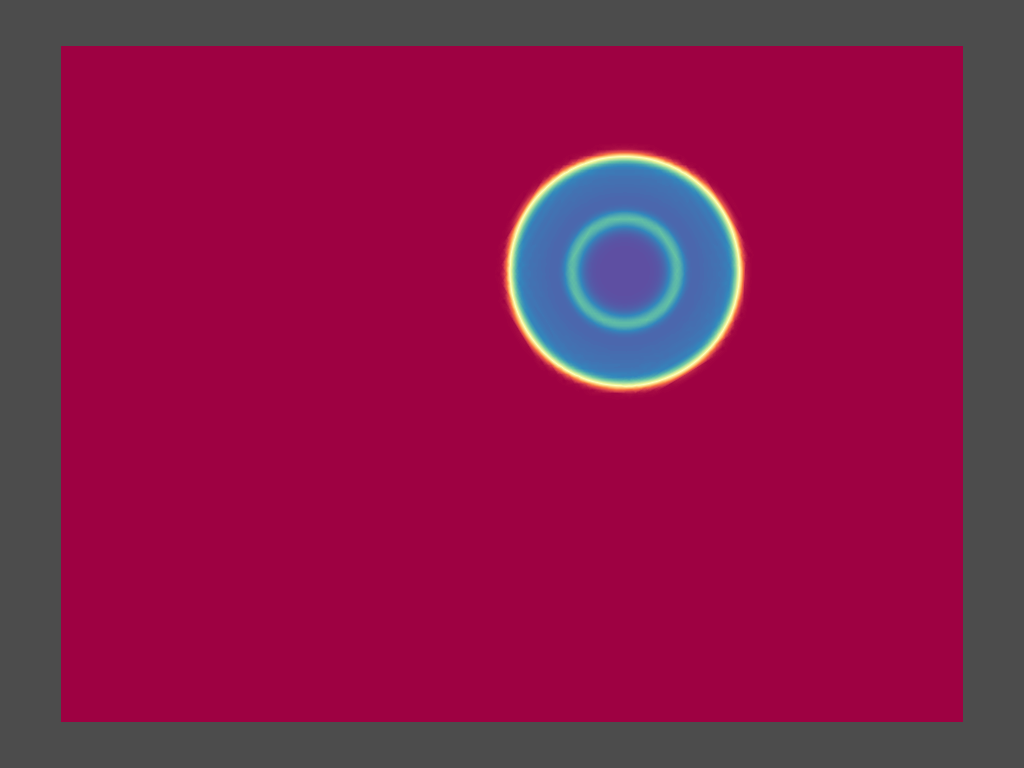

In [62]:
#cmap = 'coolwarm'
cmap = 'Spectral'
#cmap = 'viridis'
#cmap = 'magma'
#cmap = 'plasma'
plotter = pv.Plotter()
dargs = dict(cmap=cmap, clim=[0,1])
plotter.add_mesh(read, scalars='Data_@_t=4_3',show_scalar_bar=False, **dargs, lighting=False)
plotter.link_views()
plotter.camera_position = 'xy'
plotter.camera.zoom(1.5)

plotter.show()

In [168]:
dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
for ind in range(5):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(ind) + "_3",show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "const" + str(ind) + "_3.png"
    plotter.screenshot(fname)
    
for ind in range(5):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(ind) + "_2",show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "const" + str(ind) + "_2.png"
    plotter.screenshot(fname)

In [65]:
read = pv.read("Data/constructionSimple_29Dec.vtu")
plotter = pv.Plotter()

dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
idx = np.linspace(0,5,51)
fin = [int(y) if y.is_integer() else np.round(y,2) for y in idx]
# for ind in range(5):
for ind in np.arange(np.size(fin)):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(fin[ind]),show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "photor" + str(ind) + ".png"
    plotter.screenshot(fname)

In [64]:
read = pv.read("Data/constructionSimple_29Dec.vtu")
plotter = pv.Plotter()

dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
idx = np.linspace(0,5,51)
fin = [int(y) if y.is_integer() else np.round(y,2) for y in idx]
# for ind in range(5):
for ind in np.arange(np.size(fin)):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(fin[ind]) + "_3",show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "subst" + str(ind) + ".png"
    plotter.screenshot(fname)

In [63]:
read = pv.read("Data/constructionSimple_29Dec.vtu")
plotter = pv.Plotter()

dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
idx = np.linspace(0,5,51)
fin = [int(y) if y.is_integer() else np.round(y,2) for y in idx]
# for ind in range(5):
for ind in np.arange(np.size(fin)):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(fin[ind]) + "_2",show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "density" + str(ind) + ".png"
    plotter.screenshot(fname)

Deconstruction plots

In [3]:
reader = pv.get_reader("Data/deconstructionSimple_29Dec.vtu")
print(f"Number of point arrays: {reader.number_point_arrays}")
print(f"Available point data:   {reader.point_array_names}")
print(f"Number of cell arrays:  {reader.number_cell_arrays}")
print(f"Available cell data:    {reader.cell_array_names}")
print(f"Available point arrays: {reader.point_array_names}")

Number of point arrays: 303
Available point data:   ['Data_@_t=0', 'Data_@_t=0_2', 'Data_@_t=0_3', 'Data_@_t=0.1', 'Data_@_t=0.1_2', 'Data_@_t=0.1_3', 'Data_@_t=0.2', 'Data_@_t=0.2_2', 'Data_@_t=0.2_3', 'Data_@_t=0.3', 'Data_@_t=0.3_2', 'Data_@_t=0.3_3', 'Data_@_t=0.4', 'Data_@_t=0.4_2', 'Data_@_t=0.4_3', 'Data_@_t=0.5', 'Data_@_t=0.5_2', 'Data_@_t=0.5_3', 'Data_@_t=0.6', 'Data_@_t=0.6_2', 'Data_@_t=0.6_3', 'Data_@_t=0.7', 'Data_@_t=0.7_2', 'Data_@_t=0.7_3', 'Data_@_t=0.8', 'Data_@_t=0.8_2', 'Data_@_t=0.8_3', 'Data_@_t=0.9', 'Data_@_t=0.9_2', 'Data_@_t=0.9_3', 'Data_@_t=1', 'Data_@_t=1_2', 'Data_@_t=1_3', 'Data_@_t=1.1', 'Data_@_t=1.1_2', 'Data_@_t=1.1_3', 'Data_@_t=1.2', 'Data_@_t=1.2_2', 'Data_@_t=1.2_3', 'Data_@_t=1.3', 'Data_@_t=1.3_2', 'Data_@_t=1.3_3', 'Data_@_t=1.4', 'Data_@_t=1.4_2', 'Data_@_t=1.4_3', 'Data_@_t=1.5', 'Data_@_t=1.5_2', 'Data_@_t=1.5_3', 'Data_@_t=1.6', 'Data_@_t=1.6_2', 'Data_@_t=1.6_3', 'Data_@_t=1.7', 'Data_@_t=1.7_2', 'Data_@_t=1.7_3', 'Data_@_t=1.8', 'Data_@

In [172]:
read = pv.read("Data/deconstructionSimple_29Dec.vtu")
plotter = pv.Plotter()

In [189]:
dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
#cmap = 'coolwarm'
cmap = 'Spectral'
#cmap = 'viridis'
#cmap = 'magma'
#cmap = 'plasma'
dargs = dict(cmap=cmap, clim=[0,1])
plotter.add_mesh(read, scalars='Data_@_t=10_3',show_scalar_bar=False, **dargs, lighting=False)
plotter.link_views()
plotter.camera_position = 'xy'
plotter.camera.zoom(1.5)

plotter.show()

ViewInteractiveWidget(height=768, layout=Layout(height='auto', width='100%'), width=1024)

In [190]:
dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
for ind in np.arange(11):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(ind) + "_3",show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "deconst" + str(ind) + "_3.png"
    plotter.screenshot(fname)
    
for ind in np.arange(11):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(ind) + "_2",show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "deconst" + str(ind) + "_2.png"
    plotter.screenshot(fname)

In [66]:
read = pv.read("Data/deconstructionSimple_29Dec.vtu")
plotter = pv.Plotter()

dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
idx = np.linspace(0,5,51)
fin = [int(y) if y.is_integer() else np.round(y,2) for y in idx]
# for ind in range(5):
for ind in np.arange(np.size(fin)):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(fin[ind]) + "_2",show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "density" + str(ind) + ".png"
    plotter.screenshot(fname)
    
plotter = pv.Plotter()
dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
idx = np.linspace(0,5,51)
fin = [int(y) if y.is_integer() else np.round(y,2) for y in idx]
# for ind in range(5):
for ind in np.arange(np.size(fin)):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(fin[ind]) + "_3",show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "subst" + str(ind) + ".png"
    plotter.screenshot(fname)
    
plotter = pv.Plotter()
dargs = dict(cmap=cmap, clim=[0,1])
plotter = pv.Plotter(off_screen=True)
idx = np.linspace(0,5,51)
fin = [int(y) if y.is_integer() else np.round(y,2) for y in idx]
# for ind in range(5):
for ind in np.arange(np.size(fin)):
    plotter.add_mesh(read, scalars="Data_@_t=" + str(fin[ind]),show_scalar_bar=False, **dargs, lighting=False)
    plotter.link_views()
    plotter.camera_position = 'xy'
    fname = "photor" + str(ind) + ".png"
    plotter.screenshot(fname)